In [14]:
import os
nthreads = 1
os.environ["OMP_NUM_THREADS"] = str(nthreads)
os.environ["OPENBLAS_NUM_THREADS"] = str(nthreads)
os.environ["MKL_NUM_THREADS"] = str(nthreads)

In [15]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import inferagni as ia
import pandas as pd
from cmcrameri import cm
from copy import deepcopy

In [24]:
%config InlineBackend.figure_format = 'retina'

In [25]:
outdir = "nogit_out/TOI-421_b/"

In [26]:
samps = pd.read_csv(outdir+"result.csv",skiprows=1, sep=",", encoding="utf-8")
truth = pd.read_csv(outdir+"truth.csv" ,skiprows=1, sep=",", encoding="utf-8")

ntruth = len(truth)

# get last samples from samps
end_frac = 0.01
nsamp = int(len(samps)*(1-end_frac))
samps = samps.iloc[-nsamp:]

In [27]:
print(truth.keys())
print(samps.keys())

Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 't_surf', 'log_vmr_CO', 'log_vmr_H2S', 'log_vmr_CO2',
       'μ_phot', 'r_phot', 'log_vmr_H2O', 'log_vmr_H2'],
      dtype='str')


In [28]:
print(samps["μ_phot"])

175      0.002829
176      0.002611
177      0.003811
178      0.002227
179      0.002557
           ...   
17495    0.003908
17496    0.004868
17497    0.003897
17498    0.002974
17499    0.002259
Name: μ_phot, Length: 17325, dtype: float64


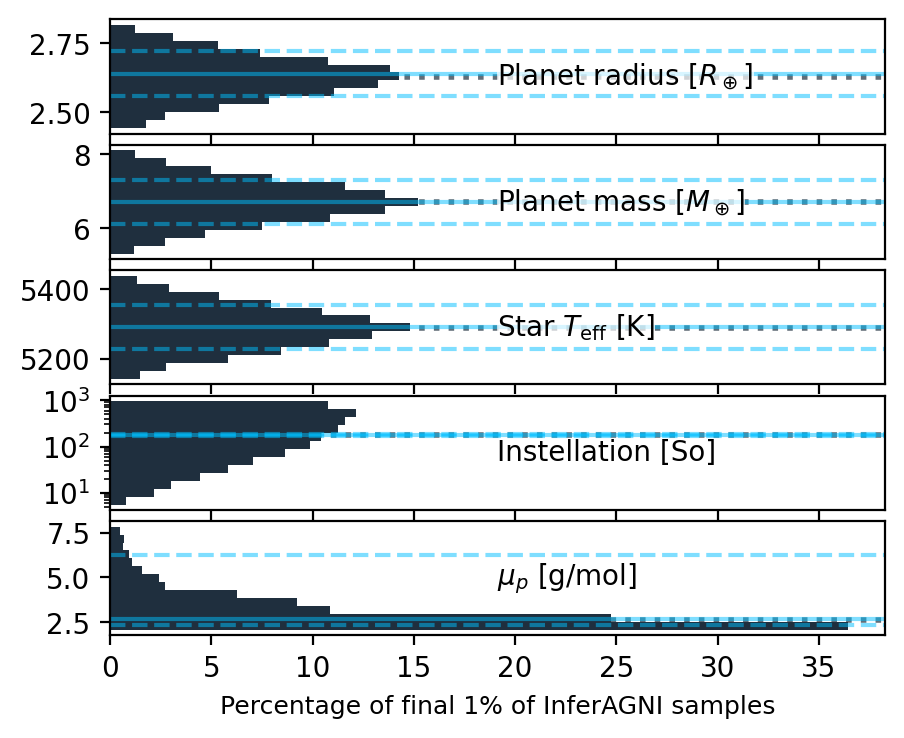

In [31]:

fig,ax = plt.subplots(ntruth,1,figsize=(5,0.8*ntruth),sharex=True)

for i in range(ntruth):
    k = truth["key"].iloc[i]

    this_samp = ia.util.undimen(deepcopy(samps[k]), k)

    pctle = 1
    ymin = np.percentile(this_samp, pctle)
    ymax = np.percentile(this_samp, 100-pctle)

    nbins = 14
    if ia.util.varprops[k].log:
        ax[i].set_yscale("log")
        bins = np.logspace(np.log10(ymin), np.log10(ymax), nbins)
    else:
        bins = np.linspace(ymin, ymax, nbins)

    # samples from mcmc
    ax[i].hist(this_samp, bins=bins, weights=np.full_like(this_samp, 100.0/len(this_samp)),
               orientation="horizontal", color=ia.retrieve.samples_color, edgecolor="none",)
    ax[i].axhline(y=np.median(this_samp), color=ia.retrieve.samples_color, ls="dotted", alpha=0.7, lw=2)

    # observations
    al = 0.5

    this_truth = deepcopy(truth.iloc[i])
    obs_val = ia.util.undimen(this_truth["value"], k)
    ax[i].axhline(obs_val, color=ia.retrieve.truth_color, ls="-", alpha=al)

    obs_err_plu = obs_val + ia.util.undimen(this_truth["plus"], k)
    ax[i].axhline(obs_err_plu, color=ia.retrieve.truth_color, ls="--", alpha=al)

    obs_err_min = obs_val - ia.util.undimen(this_truth["minus"], k)
    ax[i].axhline(obs_err_min, color=ia.retrieve.truth_color, ls="--", alpha=al)

    text = ia.util.varprops[k].label
    ax[i].text(0.5, 0.5, text, transform=ax[i].transAxes, ha="left", va="center",
                   fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.1))

ax[-1].set_xlabel(f"Percentage of final {end_frac*100:g}% of InferAGNI samples", fontsize=9)

fig.subplots_adjust(hspace=0.1)
fig.savefig(outdir+"ia_demo_truth.pdf", dpi=ia.plot.DPI, bbox_inches="tight")
plt.show()

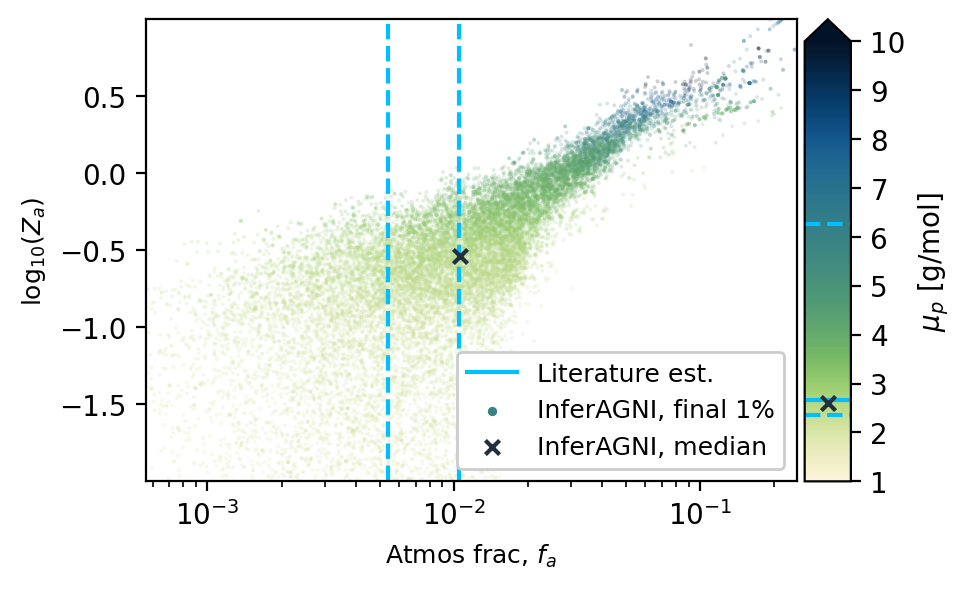

In [41]:
fig,ax = plt.subplots(1,1,figsize=(5,3))

ckey = "μ_phot"
xkey = "frac_atm"
ykey = "logZ"

if ia.util.varprops[ckey].log:
    c = 10**(samps[ckey].values)
else:
    c = samps[ckey].values
mask = np.argsort(c)[::-1]

x = ia.util.undimen(samps[xkey].iloc[mask], xkey)
y = ia.util.undimen(samps[ykey].iloc[mask], ykey)
c = ia.util.undimen(c[mask], ckey)

# create scalarmappable with defined boundaries
sm = mpl.cm.ScalarMappable(cmap=ia.util.varprops[ckey].cmap,norm=mpl.colors.Normalize(vmin=1, vmax=10, clip=True))

# colorbar
cbar = fig.colorbar(sm, ax=ax, label=ia.util.varprops[ckey].label, pad=0.01, extend='max', aspect=10)
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(1))

# add paper constraints
obs_col = ia.retrieve.truth_color
cbar.ax.axhline(ia.util.undimen(truth[truth["key"]==ckey]["value"], ckey), c=obs_col, ls='-')
cbar.ax.axhline(ia.util.undimen(truth[truth["key"]==ckey]["value"], ckey) + ia.util.undimen(truth[truth["key"]==ckey]["plus"], ckey),c=obs_col , ls='--')
cbar.ax.axhline(ia.util.undimen(truth[truth["key"]==ckey]["value"], ckey) - ia.util.undimen(truth[truth["key"]==ckey]["minus"], ckey),c=obs_col, ls='--')
for xx in (0.54/100, 1.05/100):
    ax.axvline(xx, color=obs_col, ls='--')
ax.plot([],[], color=obs_col, ls='-', label="Literature est.")

# mcmc result
label = f"InferAGNI, final {end_frac*100:g}%"
ax.scatter([],[], color=sm.to_rgba(6), s=22, marker=".", label=label, zorder=21, )
ax.scatter(x,y, c=c, s=2,  alpha=0.2, cmap=sm.get_cmap(), norm=sm.norm, edgecolors="none", rasterized=True)
ax.scatter(np.median(x), np.median(y), c=ia.retrieve.samples_color, s=26, marker="x", label="InferAGNI, median", zorder=21)
cbar.ax.scatter(0.5, np.median(c), c=ia.retrieve.samples_color, s=26, marker='x', zorder=21)

if ia.util.varprops[xkey].log:
    ax.set_xscale("log")
if ia.util.varprops[ykey].log:
    ax.set_yscale("log")
ax.set_xlabel(ia.util.varprops[xkey].label, fontsize=9)
ax.set_ylabel(ia.util.varprops[ykey].label, fontsize=9)

ax.set_xlim(np.amin(x), np.amax(x))
ax.set_ylim(np.amin(y), np.amax(y))

ax.legend(loc='lower right', fontsize=9, framealpha=1)
fig.savefig(outdir+"ia_demo_litcomp.pdf", dpi=ia.plot.DPI, bbox_inches="tight")
plt.show()